# Figure XX - mCherry Revisions

In [96]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import ticker as mticker
import seaborn as sns
import scipy
from statannotations.Annotator import Annotator
import rushd as rd
import re
from pathlib import Path
import matplotlib
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap

# Required descriptors for annotate
from scipy.stats import ttest_ind
from statannotations.stats.StatTest import StatTest
custom_long_name = 't-test for independent samples from scipy with greater 1-way (mean of the distribution underlying the first sample is greater than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_greater'
custom_func = ttest_ind
ttest_ind_greater = StatTest(custom_func, custom_long_name, custom_short_name, alternative='greater')

custom_long_name = 't-test for independent samples from scipy with less 1-way (mean of the distribution underlying the first sample is less than the mean of the distribution underlying the second sample)'
custom_short_name = 't-test_ind_less'
custom_func = ttest_ind
ttest_ind_less = StatTest(custom_func, custom_long_name, custom_short_name, alternative='less')

In [103]:
viridis = matplotlib.colormaps['viridis']

# Sample only the first 85% of the colormap
colors = viridis(np.linspace(0, 0.85, 256))

# Create a new colormap
viridis_no_yellow = LinearSegmentedColormap.from_list(
    'viridis_no_yellow',
    colors
)

In [35]:
# Set paths to the experiment folder and where to find the data
base_path = rd.datadir/'data'/'attune'/'Mary'

Plates = {'2026.07.10_exp66': ['Plate1', 'Plate2','Plate3']
}

exp_path = []
yaml_path = []

for i in Plates:
    for j in Plates[i]:
        exp_path.append(base_path/i/j/'Single_cell_csvs'/'Single_cell_csvs')
        yaml_path.append(base_path/i/j/'Single_cell_csvs'/'Single_cell_csvs'/'wells.yaml')

output_path = rd.rootdir/'output'/'Figure_XX_mCherry'
cache_path = rd.rootdir/'output'/'Figure_XX_mCherry'/'data.gzip'

plates_dict = pd.DataFrame({
    'data_path' : [exp for exp in exp_path],
    'yaml_path' : [yaml for yaml in yaml_path]
})

display(plates_dict)

,data_path,yaml_path
0,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
1,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...
2,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...,C:\Users\chemegrad202\Nextcloud\data\attune\Ma...


In [36]:
#Load data
data = pd.DataFrame()
if cache_path.is_file(): data = pd.read_parquet(cache_path)
else:
    channel_list = ['mRuby2-A', 'mRuby2-H','mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'FSC-A','TagBFP-A','TagBFP-H']
    data = rd.flow.load_groups_with_metadata(plates_dict,columns=channel_list) #Could add in columns=channel_list here to get specific columns

    # Remove NaN values
    data.dropna(inplace=True)

    # Save data in the cache path for easier loading next time
    data.to_parquet(rd.outfile(cache_path))


In [40]:
data = data.rename(columns={'mRuby2-A': 'mCherry-A', 'mRuby2-H':'mCherry-H'})

In [41]:
channel_list = ['mCherry-A', 'mCherry-H','mGL-H','mGL-A', 'iRFP670-A','iRFP670-H', 'TagBFP-A','TagBFP-H']


df_fractions=data.copy()

for channel in channel_list:
    df_fractions.loc[df_fractions[channel] <=0, channel] = 1


In [42]:
numSamples = 10**4
small_data_all = df_fractions.groupby(['cond']).sample(n=numSamples, random_state=1).copy()

In [43]:
df_no_bfp = df_fractions[df_fractions['cond'] == 'none']
bfp_threshold_hard = df_no_bfp['TagBFP-A'].quantile(0.99)
mruby_threshold = 2500

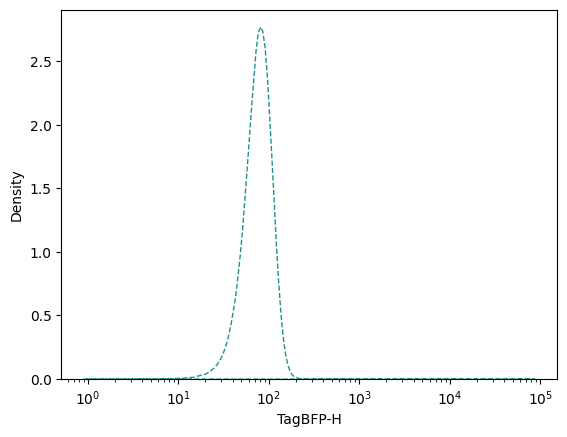

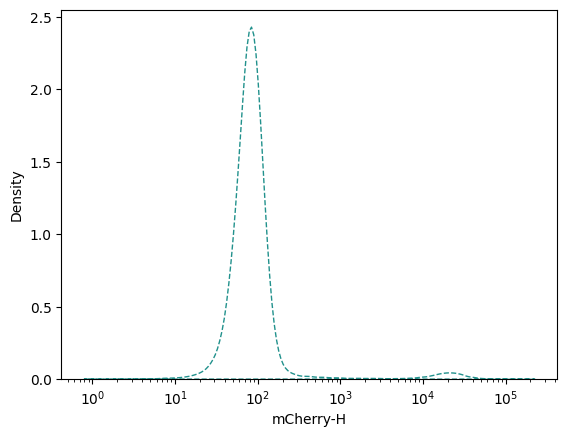

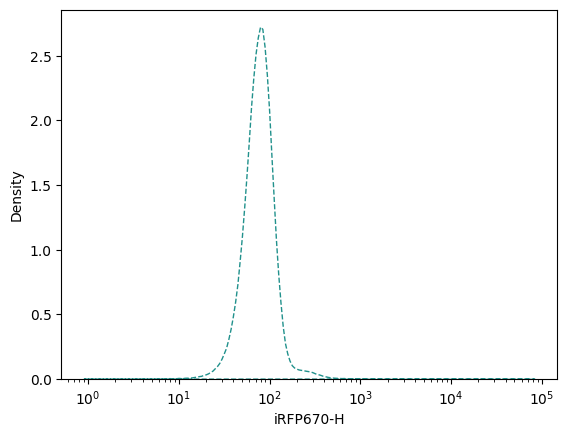

In [47]:
parameters = np.array(['TagBFP-H', 'mCherry-H', 'iRFP670-H'])
for param in parameters:
    untransfected = data[(data['cond'] == 'none')& (data[param] > 0)]
    g = plt.figure()
    sns.kdeplot(untransfected, x=param,hue='cond',log_scale=True,legend=False,fill=True,common_norm=False,palette='viridis', alpha = 0, linestyle = '--')

In [48]:
# Or use the percentile gating
iRFP_gate_quantile = untransfected['iRFP670-H'].quantile(0.99)
TagBFP_gate = 200
mRuby2_gate = 2500
display(iRFP_gate_quantile)

# # Gating on co-transfection marker
data_gated = data[data['iRFP670-H'] > iRFP_gate_quantile]

268.0

In [49]:
TagBFP_gated = data[data['TagBFP-H'] > TagBFP_gate].copy()
TagBFP_gated['mCH_cat'] = np.where(TagBFP_gated['mCherry-H'] > mRuby2_gate, 'mCH+', 'mCH-') 

In [51]:
well_group = ['cond','biorep','puro']
count_df = TagBFP_gated.groupby(['cond', 'biorep','mCH_cat','puro'])[
    'FSC-A'].count().unstack(fill_value=0).stack().rename('count')
percent_small_data_1_TagBFP = (count_df*100/count_df.groupby(well_group ).transform('sum')).reset_index(name='percent')
count_small_data_1_TagBFP = count_df.reset_index()
display(percent_small_data_1_TagBFP)

,cond,biorep,mCH_cat,puro,percent
0,desNb(mCherry),1,mCH+,0.0,9.589041
1,desNb(mCherry),1,mCH+,2.5,5.521472
2,desNb(mCherry),1,mCH+,5.0,2.500000
3,desNb(mCherry),1,mCH+,10.0,6.722689
4,desNb(mCherry),1,mCH+,20.0,3.053435
...,...,...,...,...,...
125,wtNb(mCherry)-BFP,3,mCH-,0.0,97.844301
126,wtNb(mCherry)-BFP,3,mCH-,2.5,98.078815
127,wtNb(mCherry)-BFP,3,mCH-,5.0,97.887927
128,wtNb(mCherry)-BFP,3,mCH-,10.0,97.943076


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\3141788042.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\3141788042.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([lmap[cond] for cond in order])


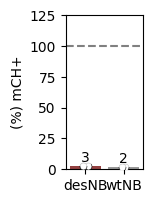

In [53]:
# General plotting params
x = 'cond'
y = 'percent'

# Conditions
order = ['desNb(mCherry)-BFP', 'wtNb(mCherry)-BFP']
mCH_cat = 'mCH+'

df = percent_small_data_1_TagBFP.loc[(percent_small_data_1_TagBFP['mCH_cat'] == mCH_cat) & (percent_small_data_1_TagBFP['puro'] == 0.0)]

palette = {
    'desNb(mCherry)-BFP': 'darkred', 
    'wtNb(mCherry)-BFP': 'grey'
}
fig, ax = plt.subplots(1, 1, figsize=(1,2))

# Plot hyperP percent of all cells
sns.barplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    palette=palette,
    alpha=0.8)

sns.stripplot(
    ax=ax, data=df,
    x=x, y=y,
    order=order,
    dodge=True,
    color='white', size=5,
    edgecolor='black', linewidth=0.4,)



lmap = {
    'desNb(mCherry)-BFP': 'desNB', 
    'wtNb(mCherry)-BFP': 'wtNB'
}
ax.set_xticklabels([lmap[cond] for cond in order])
ax.set_ylim((0, 125))
plt.axhline(y=100, color='grey', linestyle= '--')
ax.yaxis.set_label_text('(%) mCH+')
# ax.set_title('mRuby2+ | 4 dpi (Lenti) | new plasmids')
ax.set_xlabel('')

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=1)
        for label in bar_labels:
            label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))    

plottitle = 'Figure_XX_mCherry_selectivity.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

In [54]:
# Categorize cells based on iRFP670_thresh
data.loc[:, 'iRFP670_cat'] = 'iRFP670-'
data.loc[(data['iRFP670-H'] > iRFP_gate_quantile), 'iRFP670_cat'] = 'iRFP670+'

# Get total counts and percent of GFP-H+
group = [ 'cond', 'biorep', 'puro']
count_df_reps = data.groupby([*group, 'well', 'iRFP670_cat'])[
    'iRFP670-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_iRFP670_count_reps = count_df_reps.reset_index()

# Extract just the iRFP670+
data_iRFP670_percent_reps = percent_df_reps.loc[(percent_df_reps['iRFP670_cat'] == 'iRFP670+')]
data_iRFP670_count_reps = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps['iRFP670_cat'] == 'iRFP670+')]

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\1781886827.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\1781886827.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\1781886827.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\1781886827.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


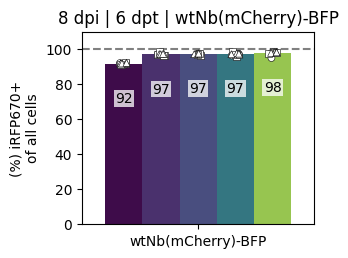

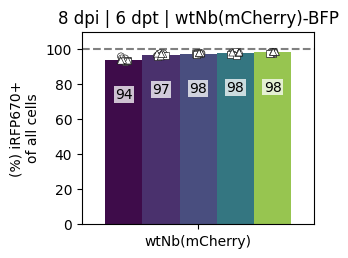

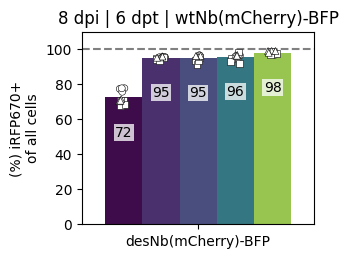

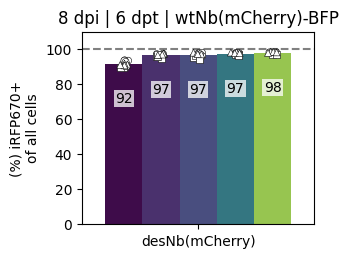

In [105]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}
palette = viridis_no_yellow

for cond in data.cond.unique():

    if (cond=='none'): continue

    curr_df = data_iRFP670_percent_reps[data_iRFP670_percent_reps.cond == cond]

    hue = antibiotic_map[cond]
    hue_order = np.sort(curr_df[hue].unique())

    # What to plot
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))

    # Plot
    sns.barplot(
        ax=ax, data=curr_df,
        x=x, y=y, ci=None, hue=hue,
        palette=palette, alpha=1)
    
    # Plot tech reps
    for (j, biorep) in enumerate(curr_df.biorep.unique()):
        sns.stripplot(
            ax=ax, data=curr_df[(curr_df.biorep == biorep)],
            x=x, y=y, hue=hue,
            dodge=True, marker=marker_list[j],
            palette={puro:'white' for puro in hue_order}, size=5,
            edgecolor='black', linewidth=0.4)
        
    # Remove legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    # Formatting
    ax.yaxis.set_label_text('(%) iRFP670+\nof all cells')
    ax.set_ylim((0, 110))
    # h,l = ax.get_legend_handles_labels()
    # sns.move_legend(ax, handles=h[-len(hue_order):], labels=l[-len(hue_order):],
    #     title=f'{hue} conc. [µg/mL]', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
    # Title
    ax.set_title(f'8 dpi | 6 dpt | {reporter}')
    ax.axhline(100, 0, 1, color='grey', linestyle='--')
    ax.set_xlabel('')
    # Add barplot labels
    for sub_ax in plt.gcf().get_axes():
        for i in sub_ax.containers:
            bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=-30)
            for label in bar_labels:
                label.set_bbox(dict(facecolor='white', alpha=0.75, linewidth=0, pad=1))
    # 
    # plt.savefig(figpath + f'bar_iRFP670-percent_{cond}.svg', bbox_inches='tight')

In [64]:
# Categorize cells based on eGFP_thresh
data.loc[:, 'mCH_cat'] = 'mCH-'
data.loc[(data['mCherry-H'] > mRuby2_gate), 'mCH_cat'] = 'mCH+'

# Gate infected cells
df_infected = data.loc[(data['iRFP670_cat'] == 'iRFP670+')]

# Get total counts and percent of GFP-H+ of the infected cells
group = [ 'cond', 'puro', 'biorep']
count_df_reps = df_infected.groupby([*group, 'well', 'mCH_cat'])[
    'mGL-H'].count().unstack(fill_value=0).stack().rename('count') # Puts 0 if no GFP-H+ rather than dropping row
percent_df_reps = (count_df_reps*100/count_df_reps.groupby([*group, 'well']).transform('sum')).reset_index(name='percent')
data_mCH_count_reps = count_df_reps.reset_index()

# Extract just the eGFP+
data_mCH_percent_reps = percent_df_reps.loc[(percent_df_reps['mCH_cat'] == 'mCH+')]
data_mCH_count_reps = data_mCH_count_reps.loc[(data_mCH_count_reps['mCH_cat'] == 'mCH+')]

In [82]:
display(data_mCH_percent_reps)

,cond,puro,biorep,well,mCH_cat,percent
0,desNb(mCherry),0.0,1,E1,mCH+,2.145883
2,desNb(mCherry),0.0,1,F1,mCH+,1.803284
4,desNb(mCherry),0.0,1,G1,mCH+,1.975335
6,desNb(mCherry),0.0,1,H1,mCH+,2.412644
8,desNb(mCherry),0.0,2,E1,mCH+,1.896926
...,...,...,...,...,...,...
478,wtNb(mCherry)-BFP,20.0,2,D10,mCH+,1.677803
480,wtNb(mCherry)-BFP,20.0,3,A10,mCH+,1.641842
482,wtNb(mCherry)-BFP,20.0,3,B10,mCH+,2.053323
484,wtNb(mCherry)-BFP,20.0,3,C10,mCH+,2.379891


In [65]:
# Convert to dataframe
data_mCH_count_reps = count_df_reps.reset_index()

# Calculate total cells per well
total_cells = (
    data_mCH_count_reps
    .groupby([*group, 'well'])['count']
    .sum()
    .reset_index(name='total_cells')
)

# Add total_cells column
data_mCH_count_reps = data_mCH_count_reps.merge(
    total_cells,
    on=[*group, 'well'],
    how='left'
)

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\1738112789.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\1738112789.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[l] for l in order])


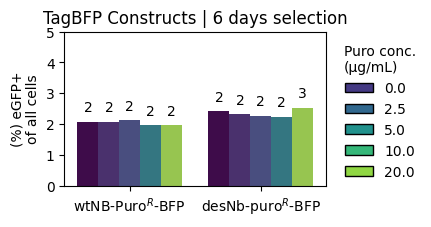

In [127]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['wtNb(mCherry)-BFP','desNb(mCherry)-BFP']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}

df_curr = data_mCH_percent_reps.loc[(data_mCH_percent_reps.cond == 'desNb(mCherry)-BFP') | (data_mCH_percent_reps.cond == 'wtNb(mCherry)-BFP')]

palette = viridis_no_yellow
hue = 'puro'
Puro_conds = np.array([0,2.5,5,10,20])

# enforce ordering based on Puro_conds
hue_order = [str(p) for p in Puro_conds if p in df_curr[hue].unique()]

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,hue_order=hue_order,
    order=order,
    palette=palette, alpha=1)


# Plot tech reps
for (j, Date) in enumerate(df_curr.biorep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.biorep == Date)],
        x=x, y=y, hue=hue, hue_order=hue_order,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro: 'white' for puro in hue_order},
        size=5,
        edgecolor='black',
        linewidth=0.4,
    )

# Create colors matching the barplot
colors = sns.color_palette('viridis', n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 5))

# Title
ax.set_title('TagBFP Constructs | 6 days selection')
ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels([label_map[l] for l in order])

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(
                dict(facecolor='white', alpha=0.75, linewidth=0, pad=1)
            )

# Make room for legend
fig.subplots_adjust(right=0.78)

plottitle = 'Figure_BFP_mCH_percent.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\3750303679.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\3750303679.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[l] for l in order])


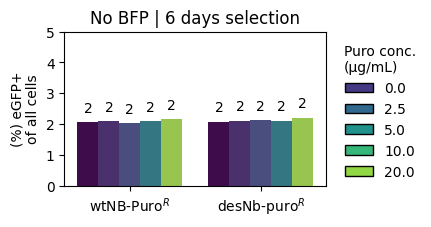

In [138]:
# General plotting params
x = 'cond'
y = 'percent'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['wtNb(mCherry)','desNb(mCherry)']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}

df_curr = data_mCH_percent_reps.loc[(data_mCH_percent_reps.cond == 'desNb(mCherry)') | (data_mCH_percent_reps.cond == 'wtNb(mCherry)')]
palette = viridis_no_yellow
hue = 'puro'
Puro_conds = np.array([0,2.5,5,10,20])

# enforce ordering based on Puro_conds
hue_order = [str(p) for p in Puro_conds if p in df_curr[hue].unique()]

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, ci=None, hue=hue,hue_order=hue_order,
    order=order,
    palette=palette, alpha=1)


# Plot tech reps
for (j, Date) in enumerate(df_curr.biorep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.biorep == Date)],
        x=x, y=y, hue=hue, hue_order=hue_order,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro: 'white' for puro in hue_order},
        size=5,
        edgecolor='black',
        linewidth=0.4,
    )

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='black', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

# Formatting
ax.yaxis.set_label_text('(%) eGFP+\nof all cells')
ax.set_ylim((0, 5))

# Title
ax.set_title('No BFP | 6 days selection')
# ax.axhline(100, 0, 1, color='grey', linestyle='--')
ax.set_xlabel('')
ax.set_xticklabels([label_map[l] for l in order])

# Add barplot labels
for sub_ax in plt.gcf().get_axes():
    for i in sub_ax.containers:
        bar_labels = sub_ax.bar_label(i, fmt='%0.0f', padding=5)
        for label in bar_labels:
            label.set_bbox(
                dict(facecolor='white', alpha=0.75, linewidth=0, pad=1)
            )

# Make room for legend
fig.subplots_adjust(right=0.78)

plottitle = 'Figure_noBFP_mCH_percent.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\2949321656.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[l] for l in order])


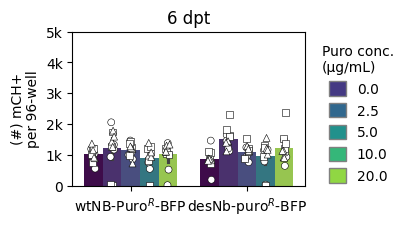

In [139]:
# General plotting params
x = 'cond'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['wtNb(mCherry)-BFP','desNb(mCherry)-BFP']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}

df_curr = data_mCH_count_reps.loc[(data_mCH_count_reps.cond == 'desNb(mCherry)-BFP') & (data_mCH_count_reps['mCH_cat'] == 'mCH+') | (data_mCH_count_reps.cond == 'wtNb(mCherry)-BFP')& (data_mCH_count_reps['mCH_cat'] == 'mCH+')]

hue = 'puro'
hue_order = np.sort(data_mCH_count_reps[hue].unique())

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, hue=hue,
    order=order,
    palette=palette, alpha=1)


# Plot tech reps
for (j, rep) in enumerate(df_curr.biorep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.biorep == rep)],
        x=x, y=y, hue=hue,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro:'white' for puro in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,legend=False)


 # Formatting
ax.yaxis.set_label_text('(#) mCH+\nper 96-well')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 5e3))

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='grey', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

# Title
ax.set_title(f'6 dpt')
ax.set_xlabel('')

plottitle = 'Figure_BFP_mCH_count.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\2794153361.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[l] for l in order])


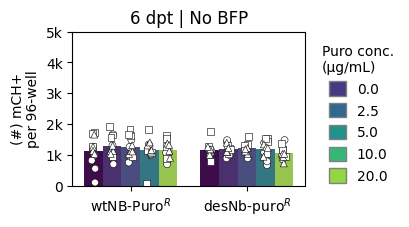

In [135]:
# General plotting params
x = 'cond'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['wtNb(mCherry)','desNb(mCherry)']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}

df_curr = data_mCH_count_reps.loc[(data_mCH_count_reps.cond == 'desNb(mCherry)') & (data_mCH_count_reps['mCH_cat'] == 'mCH+') | (data_mCH_count_reps.cond == 'wtNb(mCherry)')& (data_mCH_count_reps['mCH_cat'] == 'mCH+')]

hue = 'puro'
hue_order = np.sort(data_mCH_count_reps[hue].unique())

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y, hue=hue,
    order=order,
    palette=palette, alpha=1)


# Plot tech reps
for (j, rep) in enumerate(df_curr.biorep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.biorep == rep)],
        x=x, y=y, hue=hue,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro:'white' for puro in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,legend=False)


 # Formatting
ax.yaxis.set_label_text('(#) mCH+\nper 96-well')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 5e3))

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='grey', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

ax.legend(
    handles=legend_handles,
    title='Puro conc.\n(µg/mL)',
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)

# Title
ax.set_title(f'6 dpt | No BFP')
ax.set_xlabel('')

plottitle = 'Figure_noBFP_mCH_count.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\3549175175.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[l] for l in order])


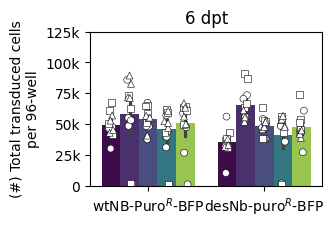

In [140]:
# General plotting params
x = 'cond'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   

order = ['wtNb(mCherry)-BFP','desNb(mCherry)-BFP']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}

df_curr = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps.cond == 'desNb(mCherry)-BFP') | (data_iRFP670_count_reps.cond == 'wtNb(mCherry)-BFP')]

hue = 'puro'
hue_order = np.sort(data_iRFP670_count_reps[hue].unique())

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y,hue=hue,
    order=order,
    palette=palette, alpha=1)


# Plot tech reps
for (j, rep) in enumerate(df_curr.biorep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.biorep == rep)],
        x=x, y=y, hue=hue,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro:'white' for puro in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,legend=False)


 # Formatting
ax.yaxis.set_label_text('(#) Total transduced cells\nper 96-well')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 125e3))

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='grey', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

# ax.legend(
#     handles=legend_handles,
#     title='Puro conc.\n(µg/mL)',
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     frameon=False,
#     handlelength=1.2,
#     handleheight=1.2
# )

# Title
ax.set_title(f'6 dpt')
ax.set_xlabel('')

plottitle = 'Figure_BFP_total_count.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\3936226570.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label_map[l] for l in order])


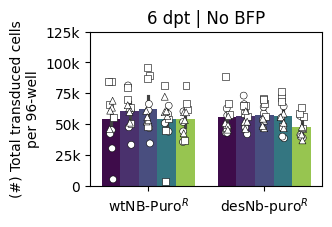

In [133]:
# General plotting params
x = 'cond'
y = 'count'
marker_list = ['o', 's', '^', 'D', 'P', 'X']   
palette = viridis_no_yellow

order = ['wtNb(mCherry)','desNb(mCherry)']

antibiotic_map = {'desNb(mCherry)-BFP':'puro', 'wtNb(mCherry)-BFP':'puro','desNb(mCherry)':'puro','wtNb(mCherry)':'puro'}


label_map = {'desNb(mCherry)-BFP':'desNb-puro$^R$-BFP',
                  'wtNb(mCherry)-BFP':'wtNB-Puro$^R$-BFP',
                  'desNb(mCherry)':'desNb-puro$^R$',
                  'wtNb(mCherry)':'wtNB-Puro$^R$'}

df_curr = data_iRFP670_count_reps.loc[(data_iRFP670_count_reps.cond == 'desNb(mCherry)') | (data_iRFP670_count_reps.cond == 'wtNb(mCherry)')]

hue = 'puro'
hue_order = np.sort(data_iRFP670_count_reps[hue].unique())

# What to plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))

# Plot
sns.barplot(
    ax=ax, data=df_curr,
    x=x, y=y,hue=hue,
    order=order,
    palette=palette, alpha=1)


# Plot tech reps
for (j, rep) in enumerate(df_curr.biorep.unique()):
    sns.stripplot(
        ax=ax, data=df_curr[(df_curr.biorep == rep)],
        x=x, y=y, hue=hue,
        order=order,
        dodge=True, marker=marker_list[j],
        palette={puro:'white' for puro in hue_order}, size=5,
        edgecolor='black', linewidth=0.4,legend=False)


 # Formatting
ax.yaxis.set_label_text('(#) Total transduced cells\nper 96-well')
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f'{x:.0f}' if abs(x) < 1000 else f'{x/1000:.0f}k'))
ax.set_xticklabels([label_map[l] for l in order])
ax.set_ylim((0, 125e3))

# Create colors matching the barplot
colors = sns.color_palette("viridis", n_colors=len(hue_order))

legend_handles = [
    Patch(facecolor=color, edgecolor='grey', label=str(puro))
    for color, puro in zip(colors, hue_order)
]

# Remove existing legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

# ax.legend(
#     handles=legend_handles,
#     title='Puro conc.\n(µg/mL)',
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     frameon=False,
#     handlelength=1.2,
#     handleheight=1.2
# )

# Title
ax.set_title(f'6 dpt | No BFP')
ax.set_xlabel('')

plottitle = 'Figure_noBFP_total_count.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')


C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\916361647.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()  # Helps improve white spacing


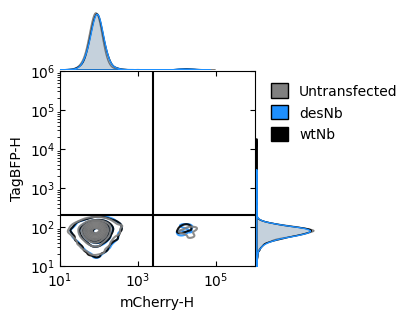

In [149]:
# General plotting params
x = "mCherry-H"
y = "TagBFP-H"
hue = "cond"

hue_order = ['desNb(mCherry)','wtNb(mCherry)','none']

# Conditions

palette = {'desNb(mCherry)-BFP':'dodgerblue',
                  'wtNb(mCherry)-BFP':'black',
                  'desNb(mCherry)':'dodgerblue',
                  'wtNb(mCherry)':'black',
                  'none': 'grey'}

# Conditions
data_new = data[(data['mCherry-H'] > 0 ) & (data['TagBFP-H'] > 0) & (data['puro'] == 20)]
untransfected = data[(data['mCherry-H'] > 0 ) & (data['TagBFP-H'] > 0) & (data['puro'] == 0) & (data['cond'] == 'none')]

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_new,untransfected])
small_data= small_data.groupby('cond').sample(n=5000, random_state=7)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)

# h,l = ax_histx.get_legend_handles_labels()
# sns.move_legend(ax_histx, handles=h, labels=l,
#     title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=1,
          label='Untransfected'),
    Patch(facecolor='dodgerblue', edgecolor='black', linewidth=1,
          label='desNb'),
    Patch(facecolor='black', edgecolor='black', linewidth=1,
          label='wtNb')
]

ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(mRuby2_gate, 0, 1, color='black')
ax_scatter.axhline(TagBFP_gate, 0, 1, color='black')

fig.tight_layout()  # Helps improve white spacing

plottitle = 'Figure_noBFP_contour.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')

C:\Users\chemegrad202\AppData\Local\Temp\ipykernel_12928\1499339236.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()  # Helps improve white spacing


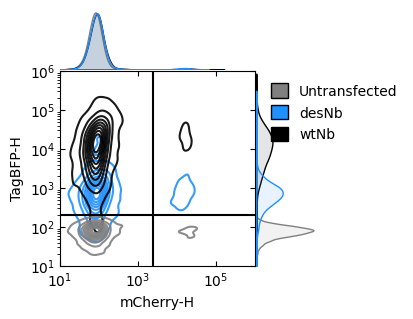

In [148]:
# General plotting params
x = "mCherry-H"
y = "TagBFP-H"
hue = "cond"

hue_order = ['desNb(mCherry)-BFP','wtNb(mCherry)-BFP','none']

# Conditions
palette = {'desNb(mCherry)-BFP':'dodgerblue',
                  'wtNb(mCherry)-BFP':'black',
                  'desNb(mCherry)':'dodgerblue',
                  'wtNb(mCherry)':'black',
                  'none': 'grey'}


# Conditions
data_new = data[(data['mCherry-H'] > 0 ) & (data['TagBFP-H'] > 0) & (data['puro'] == 20)]
untransfected = data[(data['mCherry-H'] > 0 ) & (data['TagBFP-H'] > 0) & (data['puro'] == 0) & (data['cond'] == 'none')]

# only look at no selection and iRFP+ infected
small_data = pd.concat([data_new,untransfected])
small_data= small_data.groupby('cond').sample(n=5000, random_state=7)


# definitions for the axes
left, width = 0.1, 0.65
bottom, height = 0.1, 0.65
spacing = 0.005

rect_scatter = [left, bottom, width, height]
rect_histx = [left, bottom + height + spacing, width, 0.2]
rect_histy = [left + width + spacing, bottom, 0.2, height]

# Set up figure
fig = plt.figure(figsize=(3,3))
ax_scatter = plt.axes(rect_scatter)
ax_scatter.tick_params(direction="in", top=True, right=True)
ax_histx = plt.axes(rect_histx)
ax_histx.set_axis_off()
ax_histy = plt.axes(rect_histy)
ax_histy.set_axis_off()

# Set limits
mRuby2_lim = (10, 1e6)
mCherry_lim = (10, 1e6)
ylim = mRuby2_lim
xlim = mCherry_lim
ax_scatter.set_xlim(xlim)
ax_scatter.set_ylim(ylim)
ax_histx.set_xlim(xlim)
ax_histy.set_ylim(ylim)

# Make density plots
sns.kdeplot(
    ax=ax_scatter,
    data=small_data,
    x=x, y=y, hue=hue, hue_order=hue_order,
    alpha=0.9, palette=palette,
    log_scale=True, common_norm=False, fill=False, legend=False,
)

# Plot histograms
ax_histx = sns.kdeplot(ax=ax_histx,
    data=small_data, x=x,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)
sns.kdeplot(
    ax=ax_histy,
    data=small_data,y=y,
    hue=hue, hue_order=hue_order,
    alpha=0.1, palette=palette,
    log_scale=True, fill=True, common_norm=False, legend=False,
)

# h,l = ax_histx.get_legend_handles_labels()
# sns.move_legend(ax_histx, handles=h, labels=l,
#     title='', loc='upper left', bbox_to_anchor=(1,1), frameon=False)
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='grey', edgecolor='black', linewidth=1,
          label='Untransfected'),
    Patch(facecolor='dodgerblue', edgecolor='black', linewidth=1,
          label='desNb'),
    Patch(facecolor='black', edgecolor='black', linewidth=1,
          label='wtNb')
]


ax_scatter.legend(
    handles=legend_elements,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    frameon=False,
    handlelength=1.2,
    handleheight=1.2
)
# Threshold
ax_scatter.axvline(mRuby2_gate, 0, 1, color='black')
ax_scatter.axhline(TagBFP_gate, 0, 1, color='black')

fig.tight_layout()  # Helps improve white spacing

plottitle = 'Figure_BFP_contour.svg'
plt.savefig(rd.outfile(output_path/plottitle),bbox_inches='tight')